<a href="https://colab.research.google.com/github/Ruba-Alharbi/MentalQA_NER-Reproduction/blob/main/RP_Zero_shot%26Few_shot_LLM_as_a_Judge_Results.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Final Results

## Few-shot

In [ ]:
import json, pandas as pd
from collections import Counter

# --- load JSON ---
with open("/content/few_shot_ner_judgment_results_repaired.json", "r", encoding="utf-8") as f:
    results = json.load(f)

# --- discover judgment fields in the JSON (e.g., "LLaMA Judgment") ---
judgment_fields = sorted({k for v in results.values() for k in v.keys() if k.endswith(" Judgment")})
model_names = [j.replace(" Judgment", "") for j in judgment_fields]

# verdict groups
groups = {
    "Correctness": ["accurate", "mixed", "poor"],
    "Completeness": ["full", "partial", "low"],
}

# --- count verdicts per model ---
counts = {j: {g: Counter() for g in groups} for j in judgment_fields}

for entry in results.values():
    for jf in judgment_fields:
        jd = entry.get(jf)
        if not isinstance(jd, dict):
            continue
        c  = str(jd.get("correctness", {}).get("verdict", "")).strip().lower()
        cm = str(jd.get("completeness", {}).get("verdict", "")).strip().lower()
        # Normalize alternative verdict labels produced by the Judge.
        c = {"inaccurate": "poor"}.get(c, c)
        cm = {"missing": "low"}.get(cm, cm)
        if c:  counts[jf]["Correctness"][c] += 1
        if cm: counts[jf]["Completeness"][cm] += 1

# --- Table 1: counts with multi-level headers ---
cols = [(grp, lab) for grp, labs in groups.items() for lab in labs]
data = []
for jf in judgment_fields:
    row = []
    for grp, labs in groups.items():
        row.extend([counts[jf][grp].get(l, 0) for l in labs])
    data.append(row)

summary_few = pd.DataFrame(
    data,
    index=model_names,
    columns=pd.MultiIndex.from_tuples(cols)
).astype(int)

# --- Table 2: weighted averages ---
score_map = {"accurate":2, "mixed":1, "poor":0, "full":2, "partial":1, "low":0}

def wavg(counter: Counter, labels):
    total = sum(counter.get(k, 0) for k in labels)
    return (sum(score_map[k] * counter.get(k, 0) for k in labels) / total) if total else None

avg_few = pd.DataFrame(
    {
        "Correctness Avg": [
            wavg(counts[jf]["Correctness"], groups["Correctness"]) for jf in judgment_fields
        ],
        "Completeness Avg": [
            wavg(counts[jf]["Completeness"], groups["Completeness"]) for jf in judgment_fields
        ],
    },
    index=model_names
)

In [ ]:
from IPython.display import display
display(summary_few)
display(avg_few)

Correctness            Completeness            
          accurate mixed poor         full partial low
ALLaM           16   341  142           88     367  44
GPT-4o         118   373    8          197     288  14
LLaMA          115   369   15          196     287  16

,Correctness Avg,Completeness Avg
ALLaM,0.747495,1.088176
GPT-4o,1.220441,1.366733
LLaMA,1.200401,1.360721


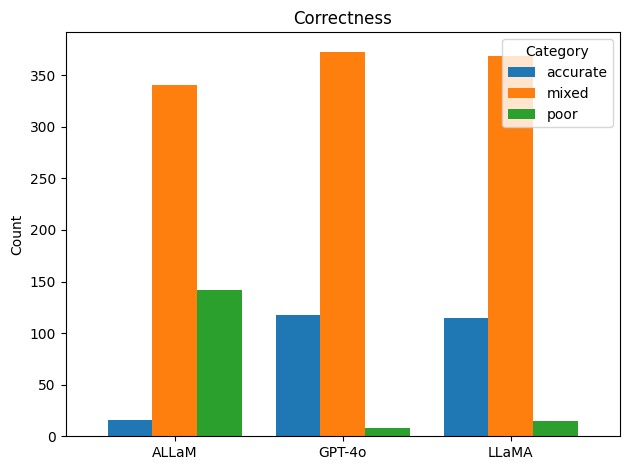

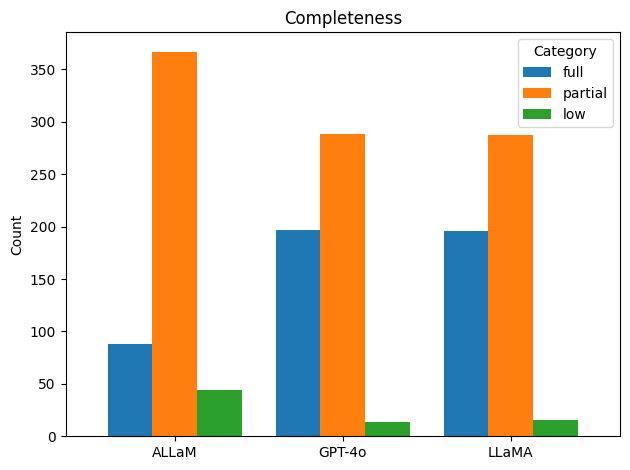

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd

# Prepare clean index
summary_plot = summary_few.copy()
if isinstance(summary_plot.index, pd.Index):
    summary_plot.index = summary_plot.index.str.replace(" Cleaned", "", regex=False)

# Extract each group from the MultiIndex
corr_df = summary_plot['Correctness'][['accurate', 'mixed', 'poor']].astype(int)
comp_df = summary_plot['Completeness'][['full', 'partial', 'low']].astype(int)

# Optional: reorder models
order = [m for m in ['ALLaM', 'GPT-4o', 'LLaMA'] if m in corr_df.index]
corr_df = corr_df.reindex(order)
comp_df = comp_df.reindex(order)

# --- Correctness chart ---
corr_df.plot(kind='bar', width=0.8)
plt.title('Correctness')
plt.ylabel('Count')
plt.legend(title='Category')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

# --- Completeness chart ---
comp_df.plot(kind='bar', width=0.8)
plt.title('Completeness')
plt.ylabel('Count')
plt.legend(title='Category')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

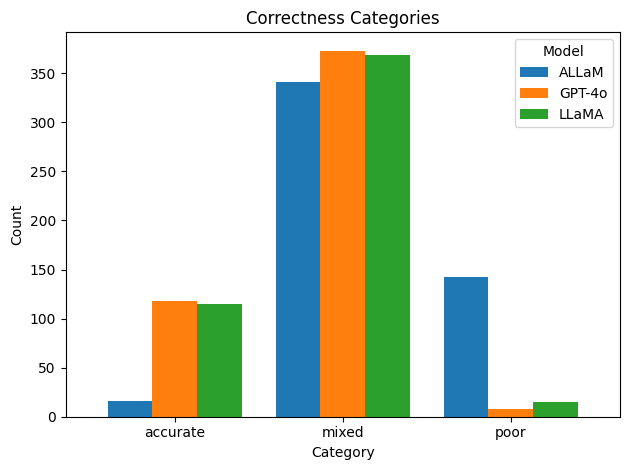

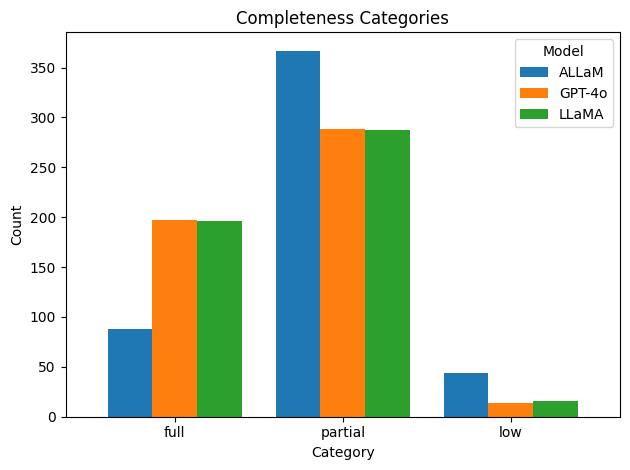

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd

# Prepare clean index
summary_plot = summary_few.copy()
if isinstance(summary_plot.index, pd.Index):
    summary_plot.index = summary_plot.index.str.replace(" Cleaned", "", regex=False)

# Extract each group from the MultiIndex
corr_df = summary_plot['Correctness'][['accurate', 'mixed', 'poor']].astype(int)
comp_df = summary_plot['Completeness'][['full', 'partial', 'low']].astype(int)

# Optional: reorder models
order = [m for m in ['ALLaM', 'GPT-4o', 'LLaMA'] if m in corr_df.index]
corr_df = corr_df.reindex(order)
comp_df = comp_df.reindex(order)

# ---- Correctness chart ----
corr_df.T.plot(kind='bar', width=0.8)
plt.title('Correctness Categories')
plt.xlabel('Category')
plt.ylabel('Count')
plt.legend(title='Model')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

# ---- Completeness chart ----
comp_df.T.plot(kind='bar', width=0.8)
plt.title('Completeness Categories')
plt.xlabel('Category')
plt.ylabel('Count')
plt.legend(title='Model')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

## Zero-shot

In [ ]:
import json, pandas as pd
from collections import Counter

# --- load JSON ---
with open("zero_shot_ner_judgment_results_retried.json", "r", encoding="utf-8") as f:
    results = json.load(f)

# --- discover judgment fields in the JSON (e.g., "LLaMA Judgment") ---
judgment_fields = sorted({k for v in results.values() for k in v.keys() if k.endswith(" Judgment")})
model_names = [j.replace(" Judgment", "") for j in judgment_fields]

# verdict groups
groups = {
    "Correctness": ["accurate", "mixed", "poor"],
    "Completeness": ["full", "partial", "low"],
}

# --- count verdicts per model ---
counts = {j: {g: Counter() for g in groups} for j in judgment_fields}

for entry in results.values():
    for jf in judgment_fields:
        jd = entry.get(jf)
        if not isinstance(jd, dict):
            continue
        c  = str(jd.get("correctness", {}).get("verdict", "")).strip().lower()
        cm = str(jd.get("completeness", {}).get("verdict", "")).strip().lower()
        # Normalize alternative verdict labels produced by the Judge.
        c = {"inaccurate": "poor"}.get(c, c)
        cm = {"missing": "low"}.get(cm, cm)
        if c:  counts[jf]["Correctness"][c] += 1
        if cm: counts[jf]["Completeness"][cm] += 1

# --- Table 1: counts with multi-level headers ---
cols = [(grp, lab) for grp, labs in groups.items() for lab in labs]
data = []
for jf in judgment_fields:
    row = []
    for grp, labs in groups.items():
        row.extend([counts[jf][grp].get(l, 0) for l in labs])
    data.append(row)

summary_zero = pd.DataFrame(
    data,
    index=model_names,
    columns=pd.MultiIndex.from_tuples(cols)
).astype(int)

# --- Table 2: weighted averages ---
score_map = {"accurate":2, "mixed":1, "poor":0, "full":2, "partial":1, "low":0}

def wavg(counter: Counter, labels):
    total = sum(counter.get(k, 0) for k in labels)
    return (sum(score_map[k] * counter.get(k, 0) for k in labels) / total) if total else None

avg_zero = pd.DataFrame(
    {
        "Correctness Avg": [
            wavg(counts[jf]["Correctness"], groups["Correctness"]) for jf in judgment_fields
        ],
        "Completeness Avg": [
            wavg(counts[jf]["Completeness"], groups["Completeness"]) for jf in judgment_fields
        ],
    },
    index=model_names
)

In [ ]:
from IPython.display import display
display(summary_zero)
display(avg_zero)

Correctness            Completeness             
          accurate mixed poor         full partial  low
ALLaM           42   294  163           54     271  174
GPT-4o         116   375    8          118     275  106
LLaMA          129   329   41          203     242   54

,Correctness Avg,Completeness Avg
ALLaM,0.757515,0.759519
GPT-4o,1.216433,1.024048
LLaMA,1.176353,1.298597


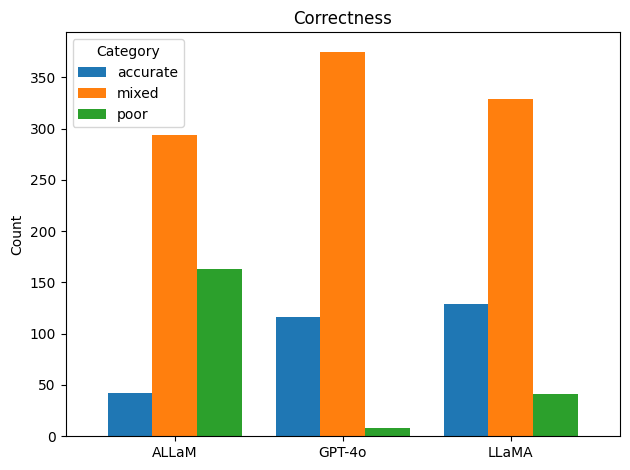

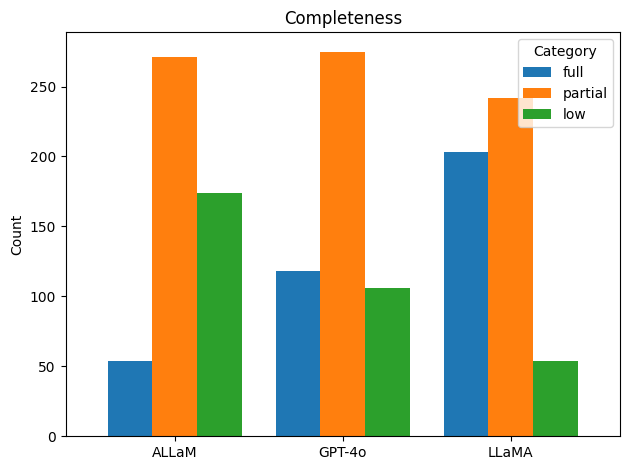

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd

# Prepare clean index
summary_plot = summary_zero.copy()
if isinstance(summary_plot.index, pd.Index):
    summary_plot.index = summary_plot.index.str.replace(" Cleaned", "", regex=False)

# Extract each group from the MultiIndex
corr_df = summary_plot['Correctness'][['accurate', 'mixed', 'poor']].astype(int)
comp_df = summary_plot['Completeness'][['full', 'partial', 'low']].astype(int)

# Optional: reorder models
order = [m for m in ['ALLaM', 'GPT-4o', 'LLaMA'] if m in corr_df.index]
corr_df = corr_df.reindex(order)
comp_df = comp_df.reindex(order)

# --- Correctness chart ---
corr_df.plot(kind='bar', width=0.8)
plt.title('Correctness')
plt.ylabel('Count')
plt.legend(title='Category')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

# --- Completeness chart ---
comp_df.plot(kind='bar', width=0.8)
plt.title('Completeness')
plt.ylabel('Count')
plt.legend(title='Category')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

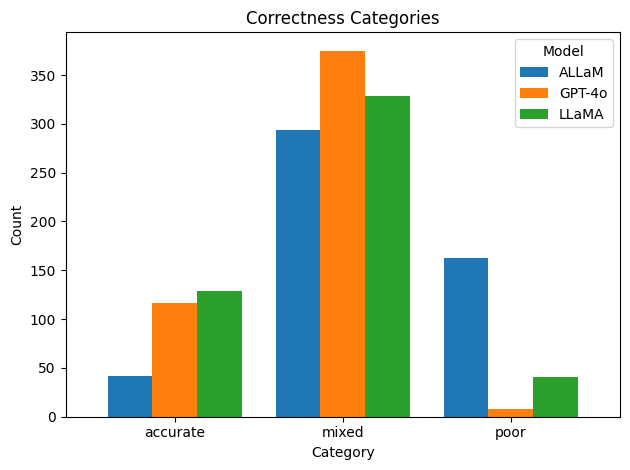

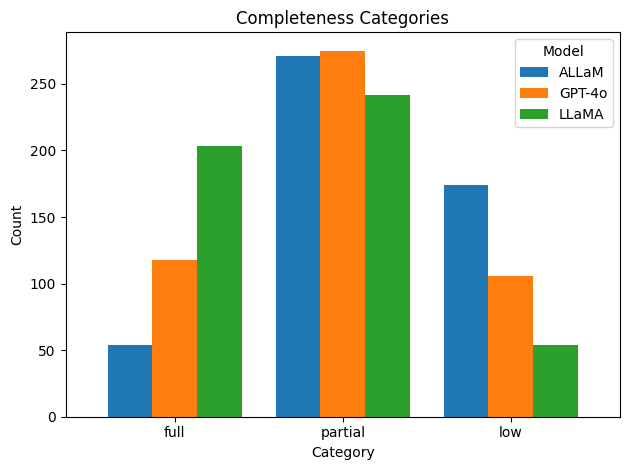

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd

# Prepare clean index
summary_plot = summary_zero.copy()
if isinstance(summary_plot.index, pd.Index):
    summary_plot.index = summary_plot.index.str.replace(" Cleaned", "", regex=False)

# Extract each group from the MultiIndex
corr_df = summary_plot['Correctness'][['accurate', 'mixed', 'poor']].astype(int)
comp_df = summary_plot['Completeness'][['full', 'partial', 'low']].astype(int)

# Optional: reorder models
order = [m for m in ['ALLaM', 'GPT-4o', 'LLaMA'] if m in corr_df.index]
corr_df = corr_df.reindex(order)
comp_df = comp_df.reindex(order)

# ---- Correctness chart ----
corr_df.T.plot(kind='bar', width=0.8)
plt.title('Correctness Categories')
plt.xlabel('Category')
plt.ylabel('Count')
plt.legend(title='Model')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

# ---- Completeness chart ----
comp_df.T.plot(kind='bar', width=0.8)
plt.title('Completeness Categories')
plt.xlabel('Category')
plt.ylabel('Count')
plt.legend(title='Model')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

## Both

In [ ]:
import json, pandas as pd
from collections import Counter

# --- point to your files ---
ZERO_PATH = "zero_shot_ner_judgment_results_retried.json"
FEW_PATH  = "/content/few_shot_ner_judgment_results_repaired.json"

# map model display names -> JSON keys that store each model's judgment
JUDGMENT_FIELDS = {
    "ALLaM":  "ALLaM Judgment",
    "GPT-4o": "GPT-4o Judgment",
    "LLaMA":  "LLaMA Judgment",
}

# verdict sets (order matters)
VERDICTS = {
    "correctness":  ["accurate", "mixed", "poor"],
    "completeness": ["full", "partial", "low"],
}

def load_json(path):
    with open(path, "r", encoding="utf-8") as f:
        return json.load(f)

def aggregate_counts(results):
    """Return counts[criterion][model] -> Counter(verdict -> count)"""
    counts = {crit: {m: Counter() for m in JUDGMENT_FIELDS} for crit in VERDICTS}
    for _, entry in results.items():
        for model, jf in JUDGMENT_FIELDS.items():
            jd = entry.get(jf)
            if not isinstance(jd, dict):
                continue
            c  = str(jd.get("correctness",  {}).get("verdict", "")).strip().lower()
            cm = str(jd.get("completeness", {}).get("verdict", "")).strip().lower()
            # Normalize alternative verdict labels produced by the Judge.
            c = {"inaccurate": "poor"}.get(c, c)
            cm = {"missing": "low"}.get(cm, cm)
            if c  in VERDICTS["correctness"]:   counts["correctness"][model][c]  += 1
            if cm in VERDICTS["completeness"]:  counts["completeness"][model][cm] += 1
    return counts

zero_counts = aggregate_counts(load_json(ZERO_PATH))
few_counts  = aggregate_counts(load_json(FEW_PATH))

# convenience: for a given criterion -> tidy DF with columns: Model, Verdict, Zero, Few
def build_compare_df(criterion):
    rows = []
    for model in JUDGMENT_FIELDS:
        for v in VERDICTS[criterion]:
            rows.append({
                "Model": model,
                "Verdict": v,
                "Zero": zero_counts[criterion][model].get(v, 0),
                "Few":  few_counts[criterion][model].get(v, 0),
            })
    return pd.DataFrame(rows)

df_corr = build_compare_df("correctness")
df_comp = build_compare_df("completeness")

In [ ]:
import json
from collections import Counter
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ======================
# 1) CONFIG
# ======================
ZERO_PATH = "/content/zero_shot_ner_judgment_results_retried.json"
FEW_PATH  = "/content/few_shot_ner_judgment_results_repaired.json"

JUDGMENT_FIELDS = {
    "ALLaM":  "ALLaM Judgment",
    "GPT-4o": "GPT-4o Judgment",
    "LLaMA":  "LLaMA Judgment",
}

VERDICTS = {
    "correctness":  ["accurate", "mixed", "poor"],
    "completeness": ["full", "partial", "low"],
}

MODEL_ORDER = ["ALLaM", "GPT-4o", "LLaMA"]  # adjust if desired

# ======================
# 2) LOAD + AGGREGATE
# ======================
def load_json(path):
    with open(path, "r", encoding="utf-8") as f:
        return json.load(f)

def aggregate_counts(results):
    """counts[criterion][model] -> Counter(verdict -> count)"""
    counts = {crit: {m: Counter() for m in JUDGMENT_FIELDS} for crit in VERDICTS}
    for _, entry in results.items():
        for model, jf in JUDGMENT_FIELDS.items():
            jd = entry.get(jf)
            if not isinstance(jd, dict):
                continue
            c  = str(jd.get("correctness",  {}).get("verdict", "")).strip().lower()
            cm = str(jd.get("completeness", {}).get("verdict", "")).strip().lower()

            # Normalize alternative verdict labels produced by the Judge.
            c = {"inaccurate": "poor"}.get(c, c)
            cm = {"missing": "low"}.get(cm, cm)

            if c  in VERDICTS["correctness"]:
                counts["correctness"][model][c] += 1
            if cm in VERDICTS["completeness"]:
                counts["completeness"][model][cm] += 1
    return counts

def counts_to_long(counts, setup_name):
    """Return tidy df with: Criterion, Model, Verdict, Count, Prompting"""
    rows = []
    for crit, per_model in counts.items():
        for model, counter in per_model.items():
            for verdict in VERDICTS[crit]:
                rows.append({
                    "Criterion": crit,
                    "Model": model,
                    "Verdict": verdict,
                    "Count": counter.get(verdict, 0),
                    "Prompting": setup_name,
                })
    return pd.DataFrame(rows)

# Build combined tidy data
zero_counts = aggregate_counts(load_json(ZERO_PATH))
few_counts  = aggregate_counts(load_json(FEW_PATH))
df_all = pd.concat(
    [counts_to_long(zero_counts, "Zero-shot"),
     counts_to_long(few_counts,  "Few-shot")],
    ignore_index=True,
)

corr_df = df_all[df_all["Criterion"] == "correctness"].copy()
comp_df = df_all[df_all["Criterion"] == "completeness"].copy()

# ======================
# 3) PLOTTING (one figure per criterion)
# ======================
def plot_criterion_one_figure(df, title, verdict_order):
    setups = ["Zero-shot", "Few-shot"]

    # Custom colors (your choices)
    custom_palette = {
        "Zero-shot": "#2B5993",   # navey blue
        "Few-shot":  "#2A9D8F",   # teal
    }

    fig, axes = plt.subplots(1, len(verdict_order), figsize=(12, 4), sharey=True)

    for ax, verdict in zip(axes, verdict_order):
        sub = df[df["Verdict"] == verdict]
        piv = (sub.pivot_table(index="Model", columns="Prompting", values="Count", fill_value=0)
                  .reindex(MODEL_ORDER))
        x = np.arange(len(piv.index))
        w = 0.38

        for setup in setups:
            vals = piv[setup].values if setup in piv.columns else np.zeros(len(x))
            xpos = x - w/2 if setup == "Zero-shot" else x + w/2
            bars = ax.bar(
                xpos, vals, width=w,
                color=custom_palette[setup], alpha=0.85,  # transparency
                label=setup if verdict == verdict_order[0] else None
            )
            # value labels
            for rect in bars:
                h = rect.get_height()
                if h > 0:
                    ax.annotate(f"{int(h)}",
                                (rect.get_x() + rect.get_width()/2, h),
                                ha="center", va="bottom", fontsize=8)

        ax.set_title(verdict.capitalize())
        ax.set_xticks(x, piv.index)
        ymax = max(10, int(np.ceil((piv.values.max() if piv.size else 0)/100.0))*100)
        ax.set_yticks(range(0, max(501, ymax+100), 100))
        ax.grid(axis="y", linestyle="--", alpha=0.35)

    axes[0].set_ylabel("Count")
    handles, labels = axes[0].get_legend_handles_labels()
    fig.legend(handles, labels, title=" ", loc="upper center", ncol=2, frameon=False)
    fig.suptitle(title, y=1.02, fontsize=13)
    plt.tight_layout()
    plt.show()

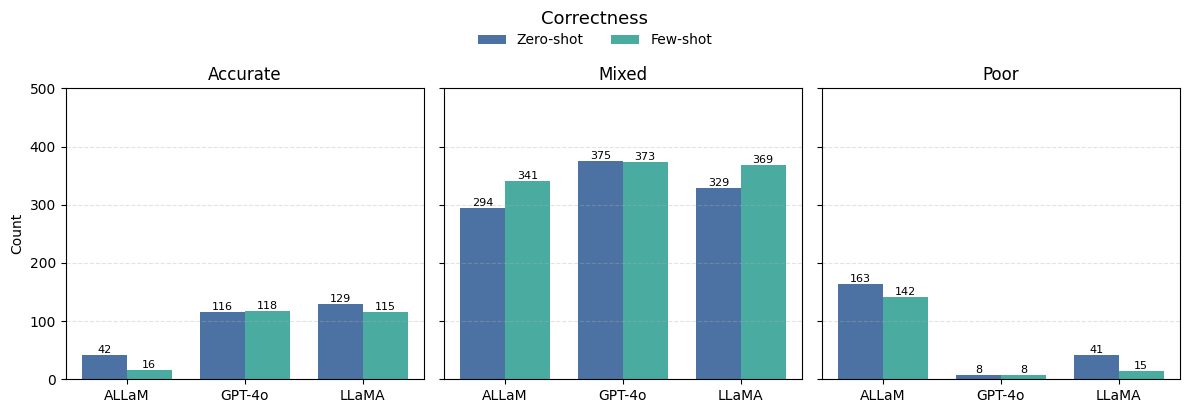

In [ ]:
plot_criterion_one_figure(corr_df, "Correctness", VERDICTS["correctness"])

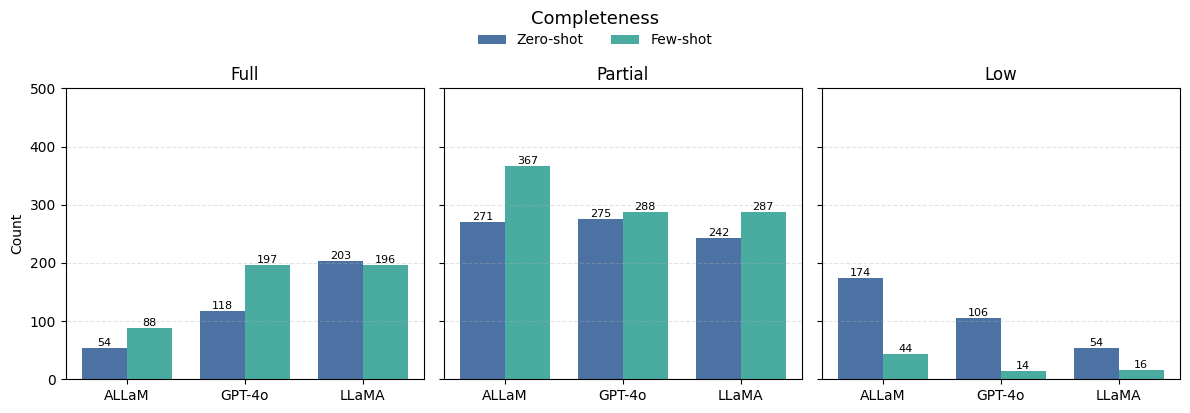

In [ ]:
plot_criterion_one_figure(comp_df, "Completeness", VERDICTS["completeness"])

In [ ]:
import json

few_file = "few_shot_ner_judgment_results_repaired.json"

with open(few_file, "r", encoding="utf-8") as f:
    few_results = json.load(f)

valid_correctness = {"accurate", "mixed", "poor", "inaccurate"}
valid_completeness = {"full", "partial", "low", "missing"}

for question, data in few_results.items():
    for field in ["ALLaM Judgment", "LLaMA Judgment"]:
        score = data.get(field, {})

        correctness = str(
            score.get("correctness", {}).get("verdict", "")
        ).strip().lower()

        completeness = str(
            score.get("completeness", {}).get("verdict", "")
        ).strip().lower()

        if (
            correctness not in valid_correctness
            or completeness not in valid_completeness
        ):
            print("\nModel:", field)
            print("Question:", question)
            print("Correctness verdict:", correctness)
            print("Completeness verdict:", completeness)